In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

## Bulk

In [9]:
pretrain_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/bulk/pretraining_bulk_RAW.h5ad")

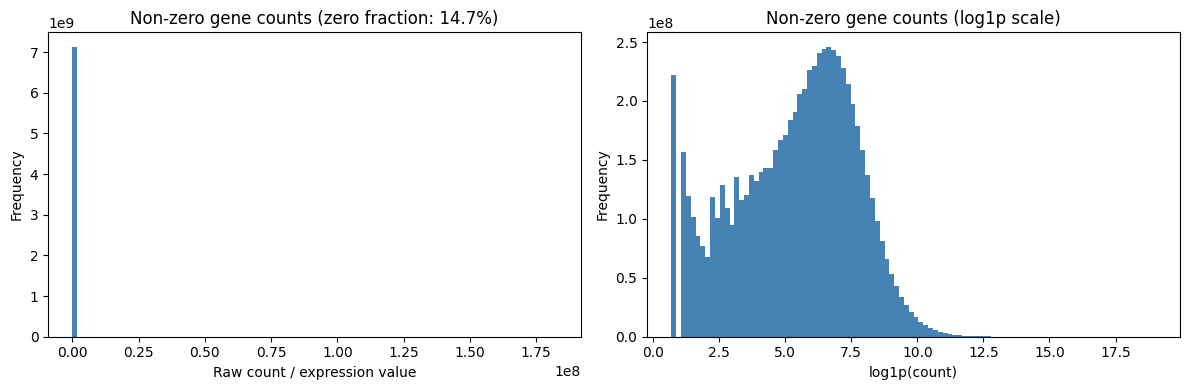

Sparsity: 14.7%
Non-zero value stats: min=1.00, median=291.00, max=182754896.00
Fraction that are exactly 1: 3.1%


In [10]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pretrain_bulk.X):
    vals = pretrain_bulk.X.data  # only non-zero entries
else:
    vals = pretrain_bulk.X[pretrain_bulk.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pretrain_bulk.n_obs * pretrain_bulk.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for bulk TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [11]:
pretrain_bulk.X.mean(axis = 1).mean()

1349.5785

[12229 12745 12699 12655 12798 12803 12831 12813 12892 12664]
mean: 11096.543855443442
median: 12152.0
min: 200
max: 13002


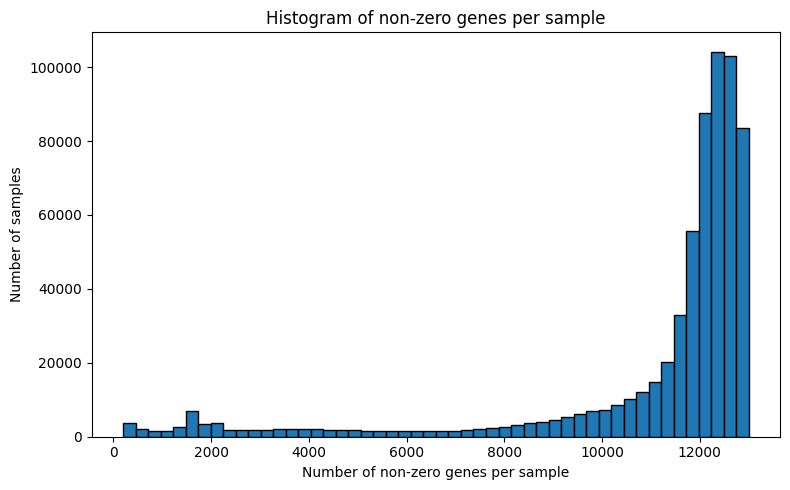

In [12]:
X = pretrain_bulk.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

### Bulk - GTEx

In [13]:
pretrain_bulk_gtex = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "GTEx"]

In [14]:
pretrain_bulk_gtex.X.mean(axis = 1).mean()

3446.0784

[12229 12745 12699 12655 12798 12803 12831 12813 12892 12664]
mean: 12784.074444756818
median: 12822.0
min: 11615
max: 12993


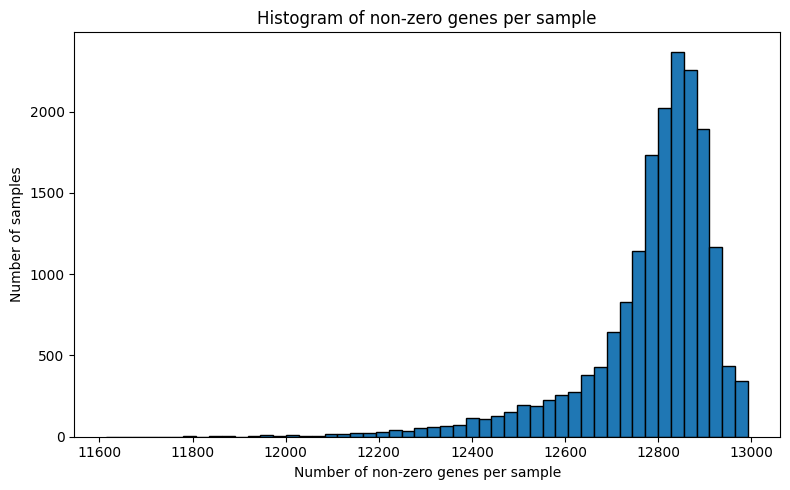

In [15]:
X = pretrain_bulk_gtex.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [16]:
del pretrain_bulk_gtex, X

### Bulk - ARCHS4

In [17]:
pretrain_bulk_archs4 = pretrain_bulk.copy()[pretrain_bulk.obs["dataset"] == "ARCHS4"]

In [18]:
del pretrain_bulk

In [19]:
pretrain_bulk_archs4.X.mean(axis = 1).mean()

1289.8846

In [20]:
pretrain_bulk_archs4.X.getnnz(axis=1).mean()

11048.49434777249

[11772 11842 11792 11770  3180  3641  3726  2992  3175  2893]
mean: 11048.49434777249
median: 12127.0
min: 200
max: 13002


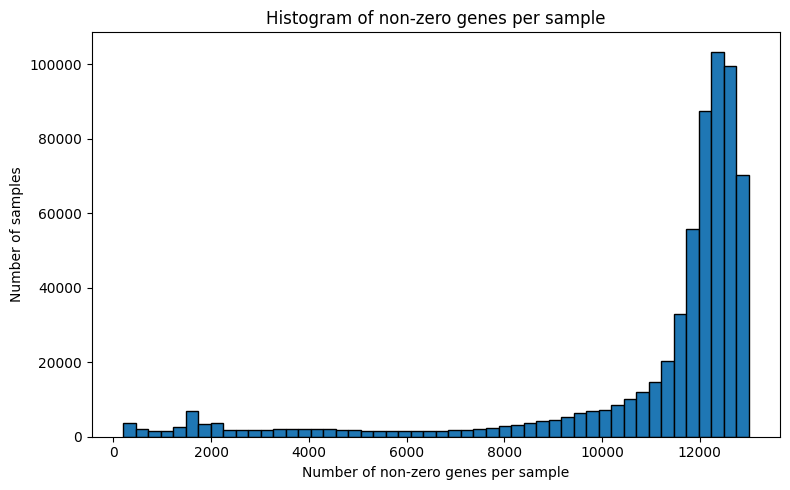

In [21]:
X = pretrain_bulk_archs4.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [22]:
del pretrain_bulk_archs4, X

## SC

In [3]:
pretrain_sc = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/sc/pretraining_sc_RAW.h5ad")

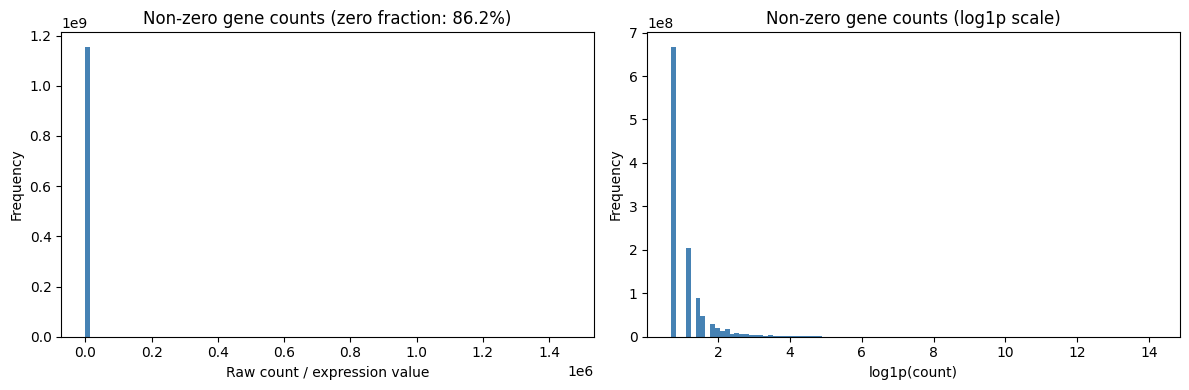

Sparsity: 86.2%
Non-zero value stats: min=1.00, median=1.00, max=1462700.00
Fraction that are exactly 1: 57.8%


In [4]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pretrain_sc.X):
    vals = pretrain_sc.X.data  # only non-zero entries
else:
    vals = pretrain_sc.X[pretrain_.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pretrain_sc.n_obs * pretrain_sc.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for sc TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [5]:
pretrain_sc.X.mean(axis = 1).mean()

0.6644363

In [6]:
pretrain_sc.X.getnnz(axis=1).mean()

1798.149200038605

[1036  448  503 1722 1665  503 1698  592 1811  805]
mean: 1798.149200038605
median: 1430.0
min: 200
max: 11517


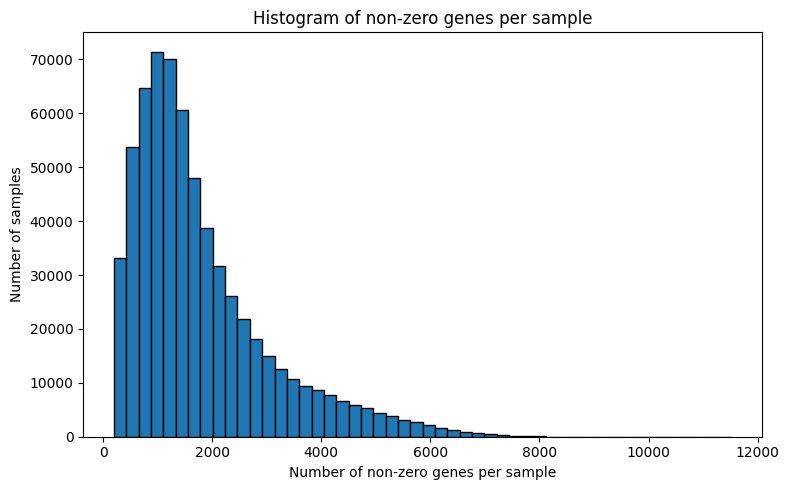

In [7]:
X = pretrain_sc.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [8]:
del pretrain_sc, X

## Cancer classification (5 types) - TCGA

In [24]:
tcga = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/TCGA/tcga.h5ad")

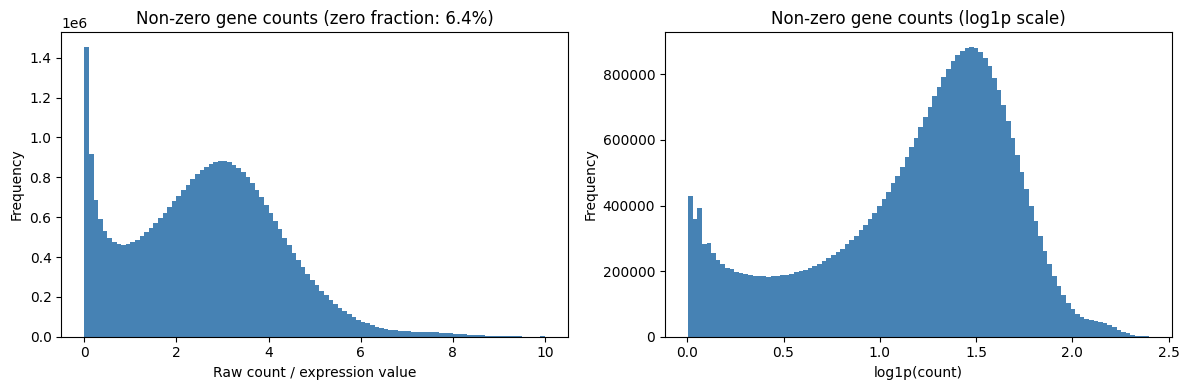

Sparsity: 6.4%
n_obs=2888, n_vars=13004
Non-zero value stats: min=0.00, median=2.69, max=10.00
Fraction that are exactly 1: 0.0%


In [25]:
cohorts = {"BRCA", "BLCA", "GBM", "LGG", "LUAD", "UCEC"}
mask = tcga.obs["project"].astype(str).isin(cohorts)
tcga = tcga[mask].copy()

# Filter to gene list
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
keep_genes = tcga.var_names.isin(gene_list)
tcga = tcga[:, keep_genes].copy()

X = tcga.X
if sparse.issparse(X):
    vals = X.data
else:
    vals = X[X > 0].ravel()

zero_frac = 1 - (len(vals) / (tcga.n_obs * tcga.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={tcga.n_obs}, n_vars={tcga.n_vars}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [26]:
tcga.X.mean(axis = 1).mean()

2.489246903525643

[12204 12145 12048 12204 12054 12164 12149 12215 12002 12191]
mean: 12171.240997229917
median: 12191.0
min: 11340
max: 12334


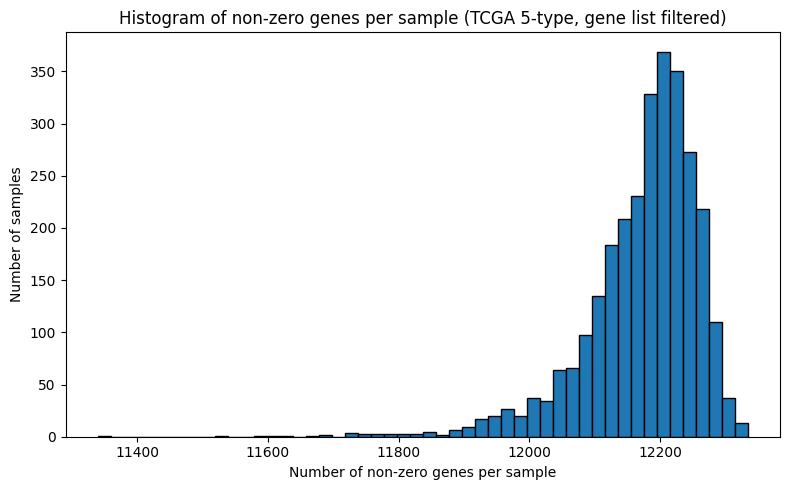

In [27]:
X = tcga.X
if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (TCGA 5-type, gene list filtered)")
plt.tight_layout()
plt.show()

del tcga

## Cancer classification (33 types) - TCGA

In [30]:
tcga = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/TCGA/tcga.h5ad")

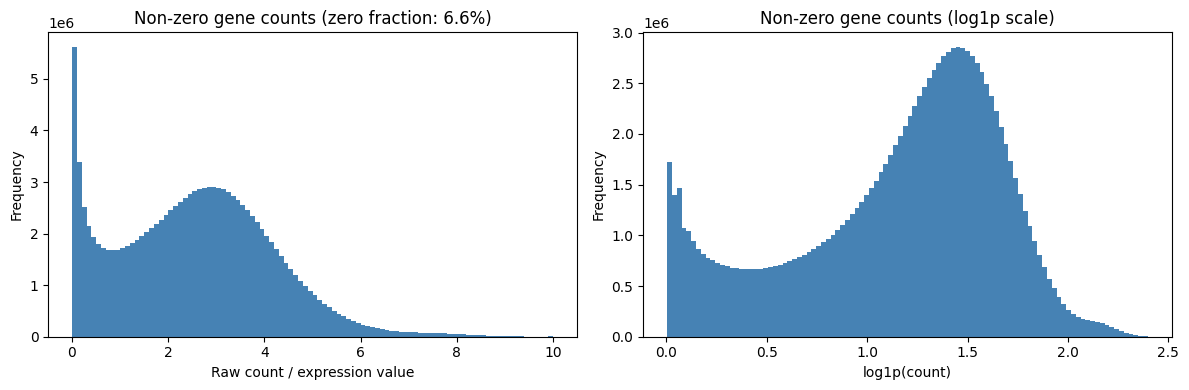

Sparsity: 6.6%
n_obs=9784, n_vars=13004
Non-zero value stats: min=0.00, median=2.58, max=10.00
Fraction that are exactly 1: 0.0%


In [31]:
cohorts_33 = {
    "ACC","BLCA","BRCA","CESC","CHOL","COAD",
    "DLBC","ESCA","GBM","HNSC","KICH","KIRC",
    "KIRP","LAML","LGG","LIHC","LUAD","LUSC",
    "MESO","OV","PAAD","PCPG","PRAD","READ",
    "SARC","SKCM","STAD","TGCT","THCA","THYM",
    "UCEC","UCS","UVM",
}
mask = tcga.obs["project"].astype(str).isin(cohorts_33)
tcga = tcga[mask].copy()

gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
tcga = tcga[:, tcga.var_names.isin(gene_list)].copy()

X = tcga.X
if sparse.issparse(X):
    vals = X.data
else:
    vals = X[X > 0].ravel()

zero_frac = 1 - (len(vals) / (tcga.n_obs * tcga.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={tcga.n_obs}, n_vars={tcga.n_vars}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [32]:
tcga.X.mean(axis = 1).mean()

2.3972544101666617

[11915 12145 12042 12024 11899 11945 12155 11992 12138 11918]
mean: 12141.426819296812
median: 12174.0
min: 3
max: 12339


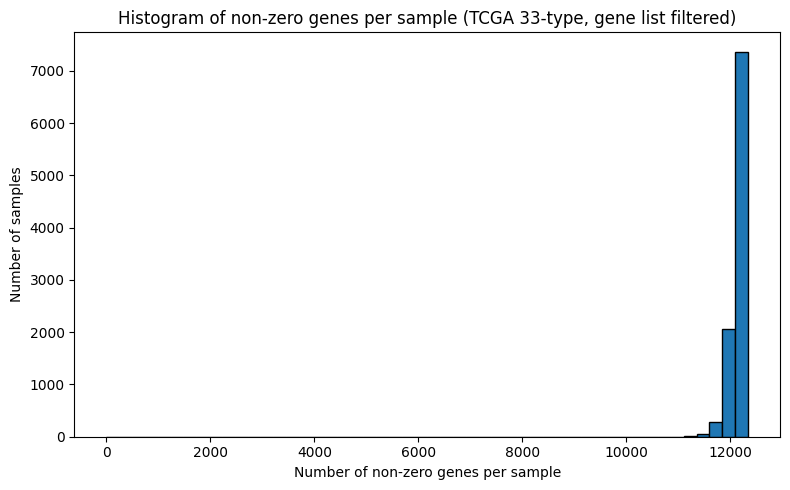

In [33]:
X = tcga.X
if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (TCGA 33-type, gene list filtered)")
plt.tight_layout()
plt.show()

In [34]:
del tcga, X

## Deconvolution - pseudo-bulk

In [23]:
pseudo_bulk = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/pseudo_bulk/pseudo_bulk_RAW.h5ad")

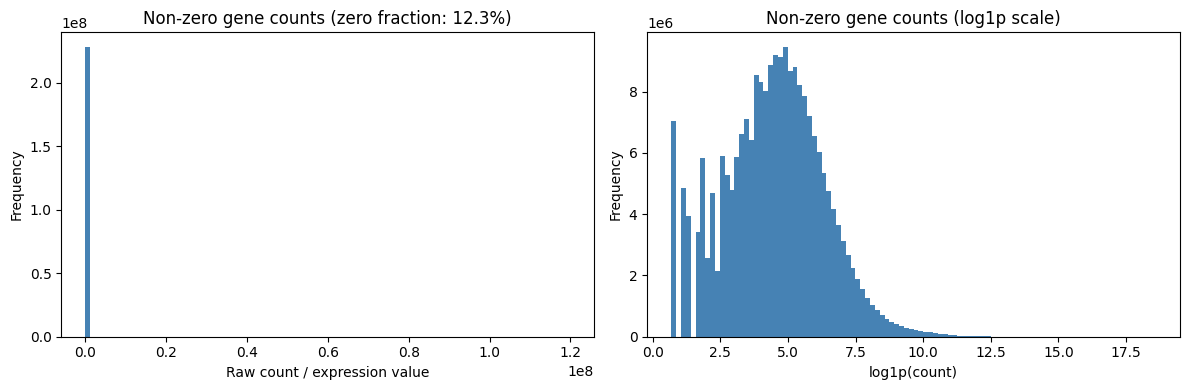

Sparsity: 12.3%
Non-zero value stats: min=1.00, median=91.00, max=119859872.00
Fraction that are exactly 1: 3.1%


In [24]:
# Extract non-zero values from sparse matrix
if sparse.issparse(pseudo_bulk.X):
    vals = pseudo_bulk.X.data  # only non-zero entries
else:
    vals = pretrain_pseudo_bulk.X[pseudo_bulk.X > 0].ravel()

zero_frac = 1 - (len(vals) / (pseudo_bulk.n_obs * pseudo_bulk.n_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Raw count / expression value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene counts (zero fraction: {zero_frac:.1%})")

# Log scale on x-axis — more informative for pseudo bulk TPM
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene counts (log1p scale)")

plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")


In [25]:
pseudo_bulk.X.mean(axis = 1).mean()

606.9196

[12084 12176 11333 12208 11861 11486 11832 11040 10311 12436]
mean: 11404.4335
median: 11709.5
min: 296
max: 12985


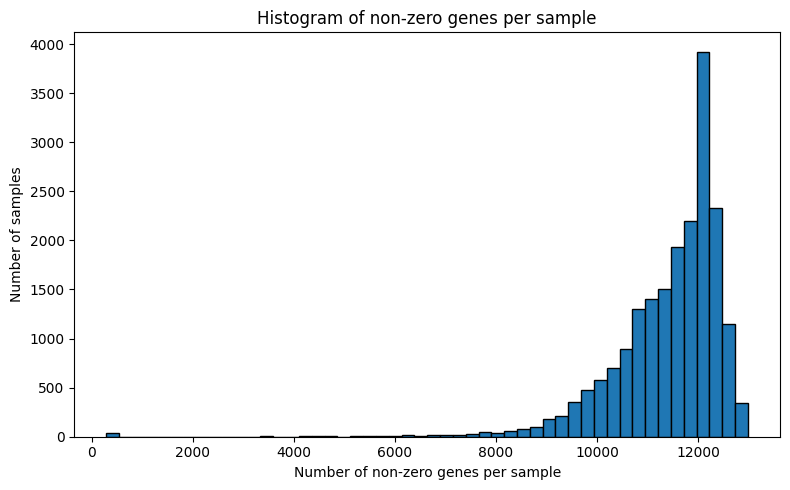

In [26]:
X = pseudo_bulk.X

if sparse.issparse(X):
    nonzero_genes_per_sample = np.asarray(X.getnnz(axis=1)).ravel()
else:
    nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:", nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:", nonzero_genes_per_sample.min())
print("max:", nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample")
plt.tight_layout()
plt.show()

In [27]:
del pseudo_bulk, X

## Disease classification - DiSignAtlas

In [40]:
dsa = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/DiSignAtlas/disignatlas.h5ad")

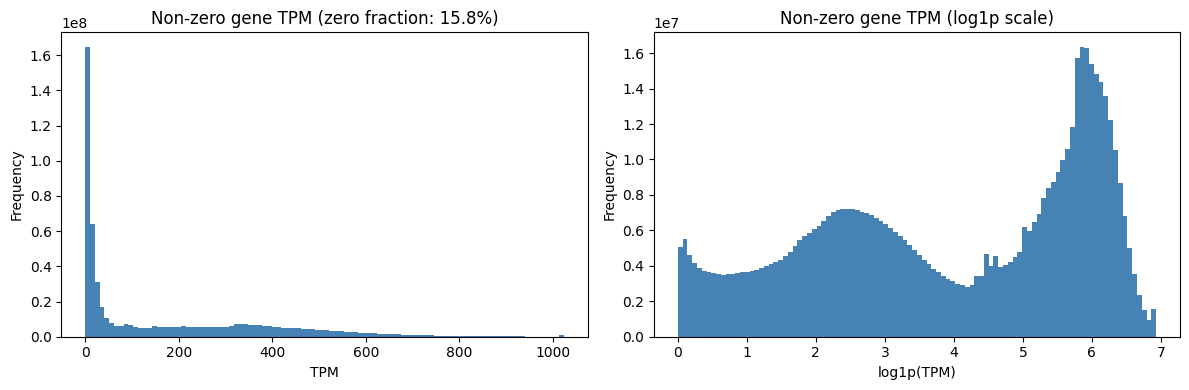

Sparsity: 15.8%
n_obs=54429, n_vars=13004
Non-zero value stats: min=0.00, median=64.56, max=1023.00
Fraction that are exactly 1: 0.0%


In [41]:
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
dsa = dsa[:, dsa.var_names.isin(gene_list)].copy()

# Denormalize: stored as log2(TPM+1) → TPM
X = dsa.X
if sparse.issparse(X):
    X = X.toarray()
X = np.exp2(X.astype(np.float32)) - 1

vals = X[X > 0].ravel()
zero_frac = 1 - (np.count_nonzero(X) / X.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("TPM")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene TPM (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(TPM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene TPM (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={dsa.n_obs}, n_vars={dsa.n_vars}")
print(f"Non-zero value stats: min={vals.min():.2f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [42]:
dsa.X.mean(axis = 1).mean()

4.7576756

[12084 12176 11333 12208 11861 11486 11832 11040 10311 12436]
mean: 11404.4335
median: 11709.5
min: 296
max: 12985


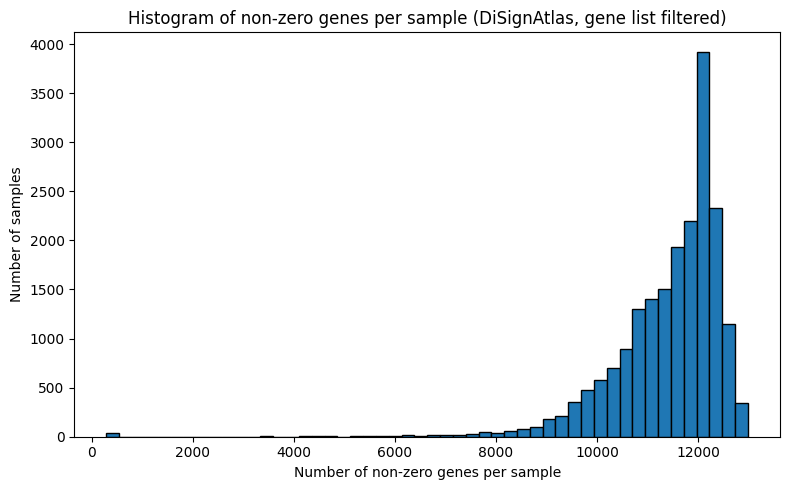

In [43]:
print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (DiSignAtlas, gene list filtered)")
plt.tight_layout()
plt.show()

In [44]:
del dsa, X

## Drug response prediction - GDSC

In [59]:
gdsc = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/GDSC/gdsc.h5ad")

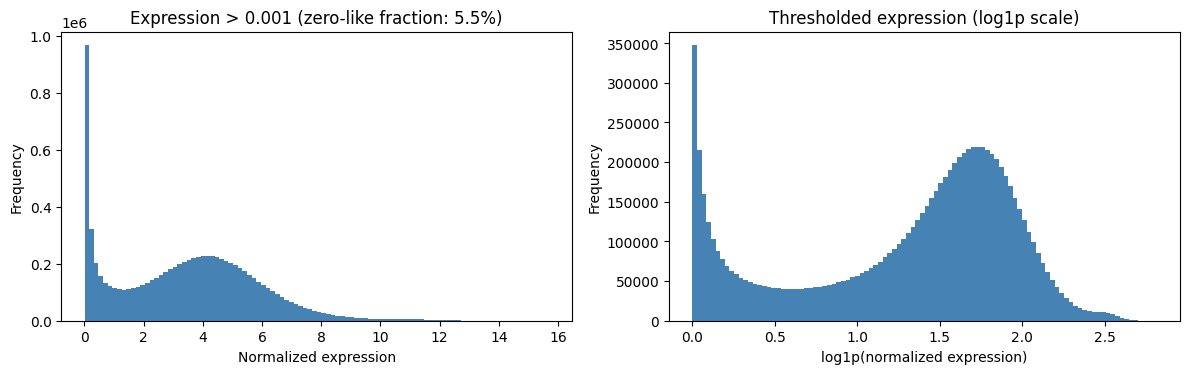

Threshold: 0.001
Zero-like fraction: 5.5%
n_obs=700, n_vars=13004
Expression stats above threshold: min=0.001002, median=3.4984, max=15.6932
Genes above threshold per sample: min=11357, median=12300, max=12817


In [65]:
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt",
    header=None,
)[0].astype(str).tolist()

gdsc = gdsc[:, gdsc.var_names.astype(str).isin(gene_list)].copy()

X = gdsc.X
if sparse.issparse(X):
    X = X.toarray()
X = np.asarray(X, dtype=np.float32)

# Values at or below this threshold are treated as zero-like.
threshold = 1e-3
expressed_mask = X > threshold
vals = X[expressed_mask].ravel()
zero_frac = np.mean(~expressed_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Normalized expression")
axes[0].set_ylabel("Frequency")
axes[0].set_title(
    f"Expression > {threshold:g} "
    f"(zero-like fraction: {zero_frac:.1%})"
)

axes[1].hist(
    np.log1p(vals),
    bins=100,
    color="steelblue",
    edgecolor="none",
)
axes[1].set_xlabel("log1p(normalized expression)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Thresholded expression (log1p scale)")

plt.tight_layout()
plt.show()

genes_per_sample = expressed_mask.sum(axis=1)

print(f"Threshold: {threshold:g}")
print(f"Zero-like fraction: {zero_frac:.1%}")
print(f"n_obs={gdsc.n_obs}, n_vars={gdsc.n_vars}")
print(
    f"Expression stats above threshold: "
    f"min={vals.min():.6f}, "
    f"median={np.median(vals):.4f}, "
    f"max={vals.max():.4f}"
)
print(
    f"Genes above threshold per sample: "
    f"min={genes_per_sample.min()}, "
    f"median={np.median(genes_per_sample):.0f}, "
    f"max={genes_per_sample.max()}"
)

In [66]:
gdsc.X.mean(axis = 1).mean()

3.2148633

[12115 12074 12255 12679 11676 12403 12243 12532 12123 12223]
mean: 12283.51857142857
median: 12300.5
min: 11357
max: 12817


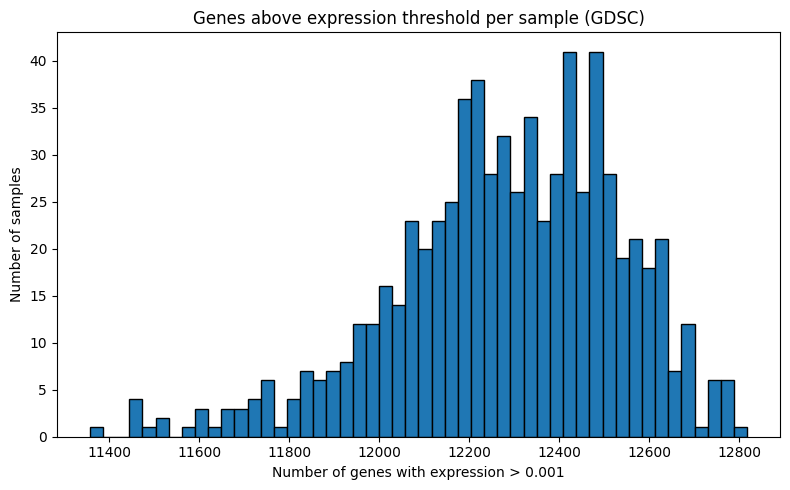

In [67]:
threshold = 1e-3

expressed_genes_per_sample = np.sum(X > threshold, axis=1)

print(expressed_genes_per_sample[:10])
print("mean:", expressed_genes_per_sample.mean())
print("median:", np.median(expressed_genes_per_sample))
print("min:", expressed_genes_per_sample.min())
print("max:", expressed_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(
    expressed_genes_per_sample,
    bins=50,
    edgecolor="black",
)
plt.xlabel(f"Number of genes with expression > {threshold:g}")
plt.ylabel("Number of samples")
plt.title("Genes above expression threshold per sample (GDSC)")
plt.tight_layout()
plt.show()

In [49]:
del gdsc, X

## Gene essentiality prediction - DepMap

In [62]:
depmap = ad.read_h5ad("/cluster/work/boeva/eheiss/datasets/DepMap/depmap.h5ad")

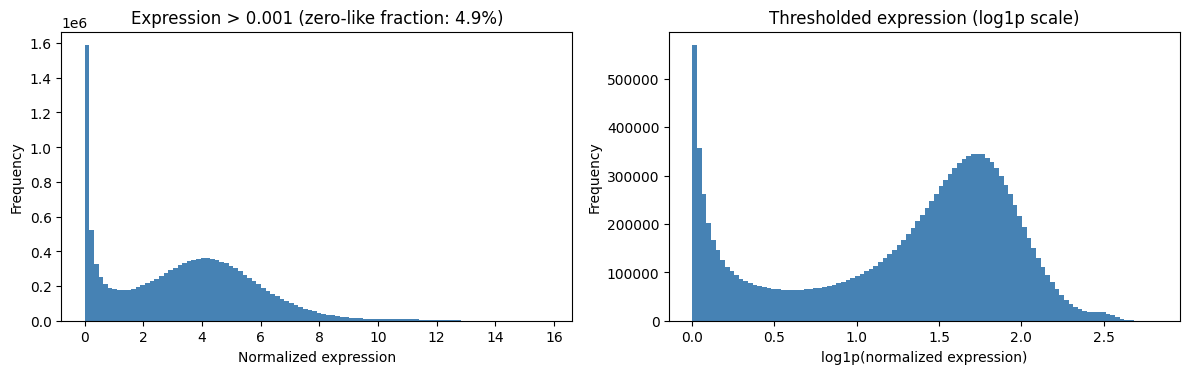

Threshold: 0.001
Zero-like fraction: 4.9%
n_obs=1103, n_vars=13004
Expression stats above threshold: min=0.001002, median=3.4636, max=15.8269
Genes above threshold per sample: min=11357, median=12404, max=12948


In [68]:
gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt",
    header=None,
)[0].astype(str).tolist()

depmap = depmap[
    :, depmap.var_names.astype(str).isin(gene_list)
].copy()

X = depmap.layers["expr_array"]
if sparse.issparse(X):
    X = X.toarray()
X = np.asarray(X, dtype=np.float32)

threshold = 1e-3
expressed_mask = X > threshold
vals = X[expressed_mask].ravel()
zero_frac = np.mean(~expressed_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Normalized expression")
axes[0].set_ylabel("Frequency")
axes[0].set_title(
    f"Expression > {threshold:g} "
    f"(zero-like fraction: {zero_frac:.1%})"
)

axes[1].hist(
    np.log1p(vals),
    bins=100,
    color="steelblue",
    edgecolor="none",
)
axes[1].set_xlabel("log1p(normalized expression)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Thresholded expression (log1p scale)")

plt.tight_layout()
plt.show()

genes_per_sample = expressed_mask.sum(axis=1)

print(f"Threshold: {threshold:g}")
print(f"Zero-like fraction: {zero_frac:.1%}")
print(f"n_obs={depmap.n_obs}, n_vars={depmap.n_vars}")
print(
    f"Expression stats above threshold: "
    f"min={vals.min():.6f}, "
    f"median={np.median(vals):.4f}, "
    f"max={vals.max():.4f}"
)
print(
    f"Genes above threshold per sample: "
    f"min={genes_per_sample.min()}, "
    f"median={np.median(genes_per_sample):.0f}, "
    f"max={genes_per_sample.max()}"
)

In [69]:
depmap.X.mean(axis = 1).mean()

3.2115281370802236

[12172 12422 12327 12276 12174 12286 12196 12547 12194 12510]
mean: 12367.116953762466
median: 12404.0
min: 11357
max: 12948


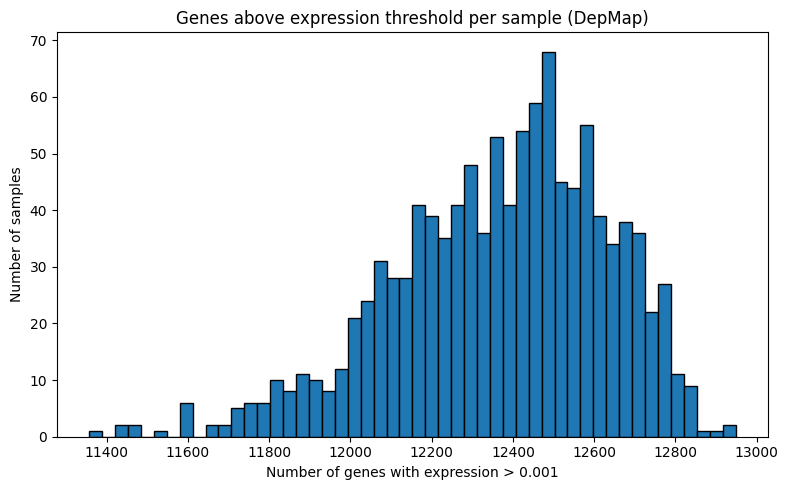

In [70]:
threshold = 1e-3

expressed_genes_per_sample = np.sum(X > threshold, axis=1)

print(expressed_genes_per_sample[:10])
print("mean:", expressed_genes_per_sample.mean())
print("median:", np.median(expressed_genes_per_sample))
print("min:", expressed_genes_per_sample.min())
print("max:", expressed_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(
    expressed_genes_per_sample,
    bins=50,
    edgecolor="black",
)
plt.xlabel(f"Number of genes with expression > {threshold:g}")
plt.ylabel("Number of samples")
plt.title("Genes above expression threshold per sample (DepMap)")
plt.tight_layout()
plt.show()

In [54]:
del depmap, X

## Survival prediction - TCGA (SurvBoard)

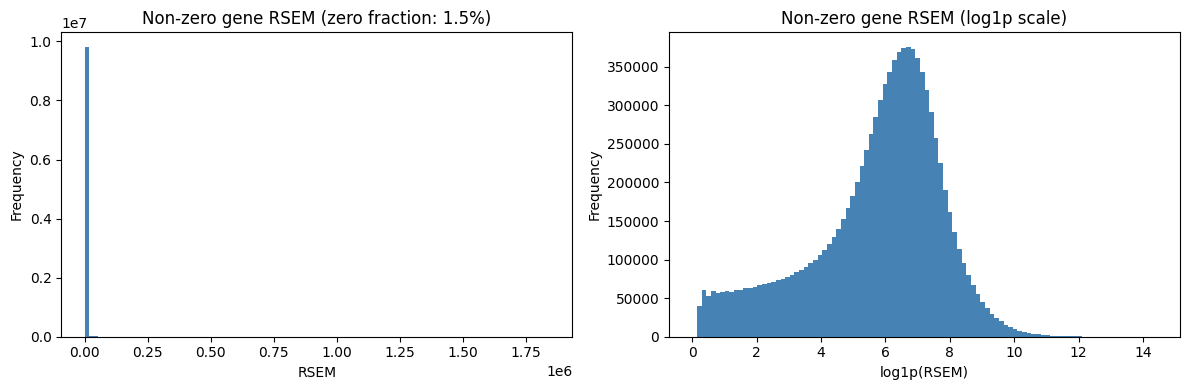

Sparsity: 1.5%
n_obs=771, n_vars=13004
Non-zero value stats: min=0.0027, median=462.80, max=1839920.25
Fraction that are exactly 1: 0.0%


In [55]:
df = pd.read_csv(
    "/cluster/work/boeva/eheiss/datasets/SurvBoard/data_reproduced/TCGA/BRCA_data_complete_modalities_preprocessed.csv",
    low_memory=False
)

gene_list = pd.read_csv(
    "/cluster/work/boeva/eheiss/scbFM/data/gene_list.txt", header=None
)[0].tolist()
gene_list_set = set(gene_list)

gene_info = pd.read_csv("/cluster/work/boeva/eheiss/scbFM/data/bulkformer_gene_info.csv")
sym2ensg = gene_info.set_index("gene_symbol")["ensg_id"].to_dict()

gex_cols = [c for c in df.columns if c.startswith("gex_")]
hugo_symbols = [c[len("gex_"):].split("|")[0] for c in gex_cols]

# Keep only columns whose HUGO maps to an ENSG in gene_list
keep_cols = [col for col, sym in zip(gex_cols, hugo_symbols)
             if sym2ensg.get(sym) in gene_list_set]

X = df[keep_cols].values.astype(np.float32)

# Denormalize: stored as log2(RSEM+1) → RSEM
X = np.exp2(X) - 1

vals = X[X > 0].ravel()
zero_frac = 1 - (np.count_nonzero(X) / X.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vals, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("RSEM")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Non-zero gene RSEM (zero fraction: {zero_frac:.1%})")
axes[1].hist(np.log1p(vals), bins=100, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log1p(RSEM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Non-zero gene RSEM (log1p scale)")
plt.tight_layout()
plt.show()

print(f"Sparsity: {zero_frac:.1%}")
print(f"n_obs={X.shape[0]}, n_vars={X.shape[1]}")
print(f"Non-zero value stats: min={vals.min():.4f}, median={np.median(vals):.2f}, max={vals.max():.2f}")
print(f"Fraction that are exactly 1: {(vals == 1).mean():.1%}")

In [56]:
X.mean(axis=1).mean()

1285.6492

[12825 12814 12934 12694 12848 12597 12843 12857 12894 12833]
mean: 12809.312581063554
median: 12829.0
min: 12292
max: 12952


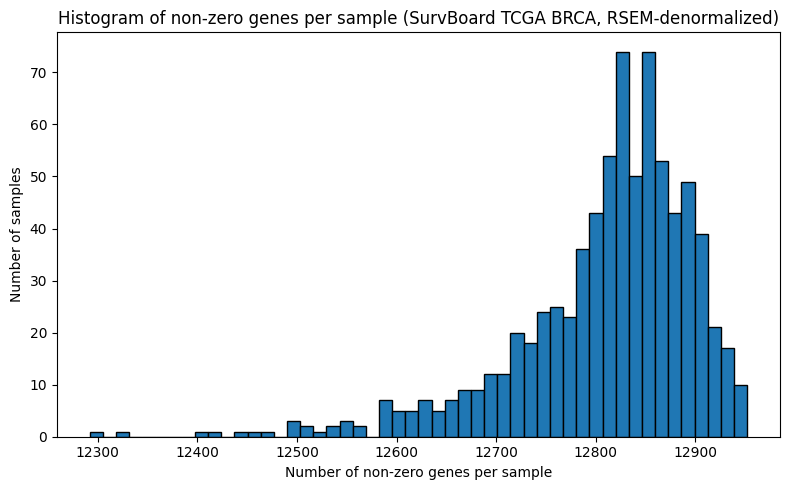

In [57]:
nonzero_genes_per_sample = np.count_nonzero(X, axis=1)

print(nonzero_genes_per_sample[:10])
print("mean:",   nonzero_genes_per_sample.mean())
print("median:", np.median(nonzero_genes_per_sample))
print("min:",    nonzero_genes_per_sample.min())
print("max:",    nonzero_genes_per_sample.max())

plt.figure(figsize=(8, 5))
plt.hist(nonzero_genes_per_sample, bins=50, edgecolor="black")
plt.xlabel("Number of non-zero genes per sample")
plt.ylabel("Number of samples")
plt.title("Histogram of non-zero genes per sample (SurvBoard TCGA BRCA, RSEM-denormalized)")
plt.tight_layout()
plt.show()

In [58]:
del df, X